In [2]:
pip install pygfunction

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pygfunction]
Note: you may need to restart the kernel to use updated packages.


In [9]:
# -*- coding: utf-8 -*-
""" Calculation of g-functions with:
    1) Custom borehole geometry from CSV file
    2) Custom heat injection/extraction rates from CSV file
    3) Multi-layer ground from CSV file
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pygfunction as gt


In [62]:
geometry_file = 'borehole_geometry.csv'
geometry_txt = 'borehole_geometry.txt'
layers_csv = 'ground_layers.csv'
profile_csv = 'heat_load_profile.csv'

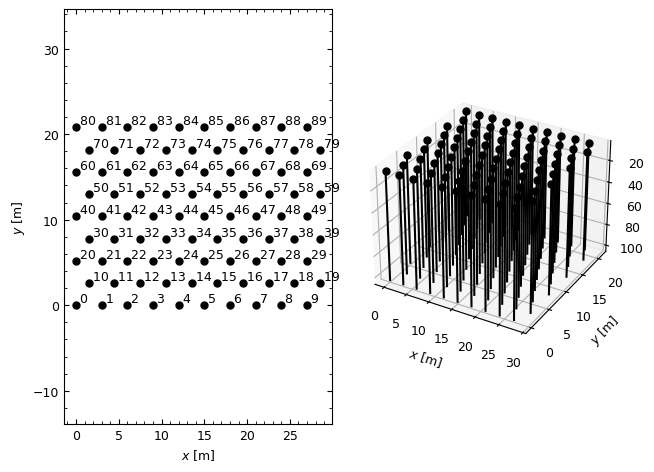

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import pygfunction as gt

def read_borehole_geometry(csv_file):
    """
    Read borehole geometry from CSV file.
    Expected columns: x, y, [optional: H, D, r_b]
    Returns borehole field object and DataFrame
    """
    df = pd.read_csv(geometry_file, sep = ',')
    df.to_csv(geometry_txt,header = False, index = False, sep = ' ')
    
    try:
        bore_field = gt.borefield.Borefield.from_file(geometry_txt)
        
        # Create borehole field object
        gt.boreholes.visualize_field(
            bore_field,
        )
        
        plt.tight_layout()
        plt.show()
        
        return bore_field
    
    except FileNotFoundError:
        print(f"Error: Geometry file '{csv_file}' not found.")
        return None, None, None

bore_field = read_borehole_geometry(geometry_txt)
boreholes = list(bore_field)


                                          Layer name  depth [m]  \
0  US/RBC_11-14 Formations quaternaires indiffére...        0.0   
1                           US/RBC_42 Sables de Lede        2.9   
2                      US/RBC_43 Sables de Bruxelles        3.6   
3                      US/RBC_43 Sables de Bruxelles       36.0   
4  US/RBC_72 Sables et argiles de Kortrijk (membr...       61.5   
5  US/RBC_73 Argiles de Kortrijk (membre de Saint...       92.1   
6    US/RBC_82 Argiles de Hannut (Membre de Lincent)       99.8   
7                        US/RBC_92 Socle Paleozoique      120.0   

   Thickness [m]  Conductivity [W/m.K]  Diffusivity [m2/s]  RhoCp [J/m3.K]  \
0            2.9                  1.90        9.500000e-07            2.30   
1            0.7                  1.65        1.150000e-06            2.40   
2           32.4                  1.65        1.100000e-06            2.45   
3           25.5                  2.60        1.100000e-06            2.45   
4     

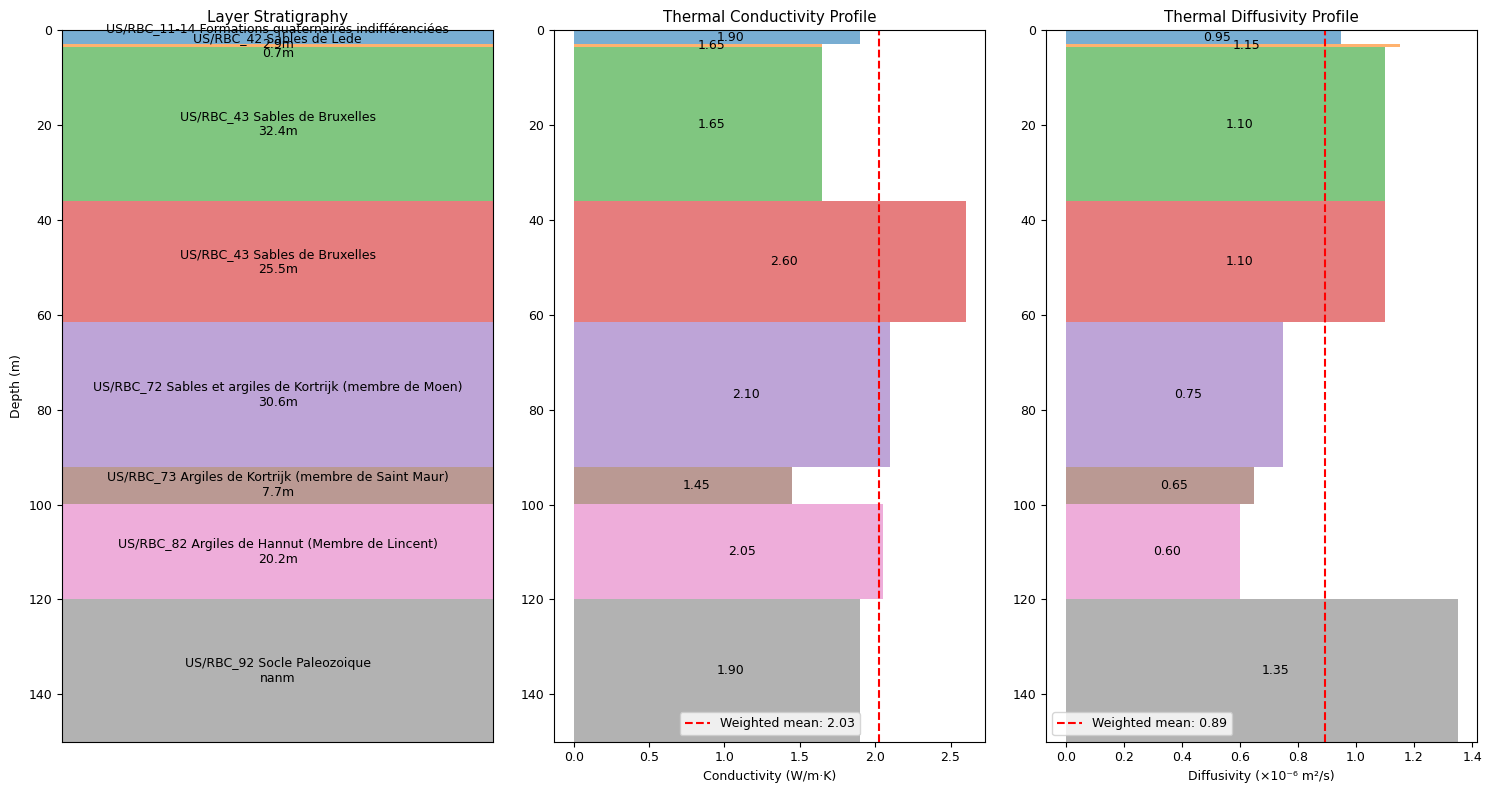

2.0271666666666666 8.943749999999999e-07 2.44175 12.5


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_layers(filepath):
    df = pd.read_csv(filepath, delimiter=',')
    print(df)
    # Calculate means
    weights = df['Thickness [m]']
    k_harmonic =         (weights * df['Conductivity [W/m.K]']).sum()  / weights.sum() 
    alpha_harmonic =     (weights * df['Diffusivity [m2/s]']).sum()    / weights.sum() 
    rhoCp_mean =         (weights * df['RhoCp [J/m3.K]']).sum()        / weights.sum()
    T_mean =             (weights * df['Temperature [Celsius]']).sum() / weights.sum()
    
    print(f"Properties:")
    print(f"  Weighted mean conductivity: {k_harmonic:.3f} W/m·K")
    print(f"  Weighted mean diffusivity: {alpha_harmonic:.2e} m²/s")
    print(f"  Weighted mean rhoCp: {rhoCp_mean/1e6:.2f} MJ/m³·K")
    
    # Plot layers
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 8))
    
    # Layer depth plot
    depths = df['depth [m]'].tolist() + [150]
    for i, (_, row) in enumerate(df.iterrows()):
        ax1.fill_between([0, 1], depths[i], depths[i+1], 
                        alpha=0.6, label=row['Layer name'])
        ax1.text(0.5, (depths[i] + depths[i+1])/2, 
                f"{row['Layer name']}\n{row['Thickness [m]']}m", 
                ha='center', va='center')
    ax1.set_ylabel('Depth (m)')
    ax1.set_title('Layer Stratigraphy')
    ax1.set_ylim(depths[-1], 0)
    ax1.set_xlim(0, 1)
    ax1.set_xticks([])
    
    # Conductivity profile
    for i, (_, row) in enumerate(df.iterrows()):
        ax2.fill_between([0, row['Conductivity [W/m.K]']], 
                        depths[i], depths[i+1], alpha=0.6)
        ax2.text(row['Conductivity [W/m.K]']/2, (depths[i] + depths[i+1])/2,
                f"{row['Conductivity [W/m.K]']:.2f}", va='center')
    ax2.axvline(k_harmonic, color='red', linestyle='--', 
                label=f'Weighted mean: {k_harmonic:.2f}')
    ax2.set_xlabel('Conductivity (W/m·K)')
    ax2.set_title('Thermal Conductivity Profile')
    ax2.set_ylim(depths[-1], 0)
    ax2.legend()
    
    # Diffusivity profile
    for i, (_, row) in enumerate(df.iterrows()):
        ax3.fill_between([0, row['Diffusivity [m2/s]']*1e6], 
                        depths[i], depths[i+1], alpha=0.6)
        ax3.text(row['Diffusivity [m2/s]']*1e6/2, (depths[i] + depths[i+1])/2,
                f"{row['Diffusivity [m2/s]']*1e6:.2f}", va='center')
    ax3.axvline(alpha_harmonic*1e6, color='red', linestyle='--',
                label=f'Weighted mean: {alpha_harmonic*1e6:.2f}')
    ax3.set_xlabel('Diffusivity (×10⁻⁶ m²/s)')
    ax3.set_title('Thermal Diffusivity Profile')
    ax3.set_ylim(depths[-1], 0)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()
    
    return k_harmonic, alpha_harmonic, rhoCp_mean, T_mean

# Usage
k, alpha, rhoCp, T_ground = analyze_layers(layers_csv)
print(k, alpha, rhoCp, T_ground)


Reading heat load profile from: heat_load_profile.csv
Found 8760 time steps
Time range: 2026-01-01 00:00:00 to 2026-12-31 23:00:00 hours
Load range: .0f to .0f W
Net load (sum): 1751767326 W·h
Average load: 199973 W
Heating hours (positive): 4943 (56.4%)
Cooling hours (negative): 3817 (43.6%)
Neutral hours: 0 (0.0%)


<Axes: xlabel='time'>

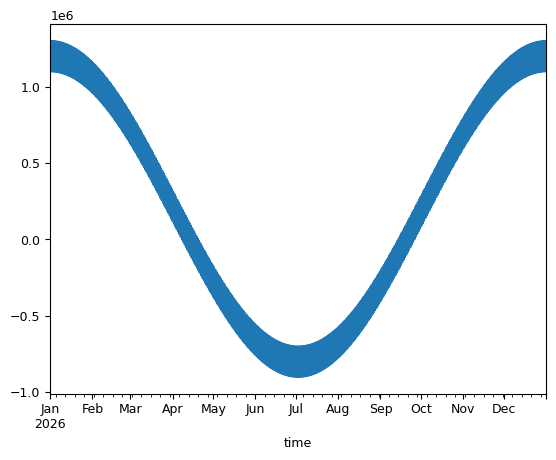

In [93]:
def read_heat_load_profile(csv_file):
    """
    Read heat load profile from CSV file.
    Expected columns: hour, load (W) [negative for extraction, positive for injection]
    """
    try:
        # Try with month/day/year format
        df = pd.read_csv(
            csv_file,
            parse_dates=['time'],
            date_format='%m/%d/%y %I:%M %p',
            index_col = 'time'
        )
        print(f"\nReading heat load profile from: {csv_file}")
        print(f"Found {len(df)} time steps")

        # Calculate statistics
        print(f"Time range: {df.index.min()} to {df.index.max()} hours")
        print(f"Load range: {df.index.min():.0f} to {df.index.max():.0f} W")
        print(f"Net load (sum): {df['load'].sum():.0f} W·h")
        print(f"Average load: {df['load'].mean():.0f} W")
        
        # Calculate heating vs cooling
        heating_hours = (df['load'] > 0).sum()
        cooling_hours = (df['load'] < 0).sum()
        neutral_hours = (df['load'] == 0).sum()
        
        print(f"Heating hours (positive): {heating_hours} ({heating_hours/len(df)*100:.1f}%)")
        print(f"Cooling hours (negative): {cooling_hours} ({cooling_hours/len(df)*100:.1f}%)")
        print(f"Neutral hours: {neutral_hours} ({neutral_hours/len(df)*100:.1f}%)")
        
        return df
    
    except FileNotFoundError:
        print(f"Error: Heat load file '{csv_file}' not found.")
        return None

load_df = read_heat_load_profile(profile_csv)
load_df['load'].plot()

In [130]:
# Simulation time# Convert DatetimeIndex → seconds since start
time_s = (load_df.index - load_df.index[0]).total_seconds().values
tmax = time_s[-1]

# g-function time vector
dt = 24 * 3600
Nt = 50
time_g = gt.utilities.time_geometric(dt, tmax, Nt)

options = {
    "nSegments": 12,
    "disp": True,
}

gfunc = gt.gfunction.gFunction(
    boreholes,
    alpha,
    time=time_g,
    boundary_condition="UHTR",
    method="similarities",
    options=options
)

print("g-function computed.")


Identifying similarities ... 0.007 sec
------------------------------------------------------------
   Calculating g-function for boundary condition : 'UHTR'   
------------------------------------------------------------
Calculating segment to segment response factors ... 0.794 sec
Building and solving the system of equations ... 0.304 sec
Total time for g-function evaluation: 1.106 sec
------------------------------------------------------------
g-function computed.


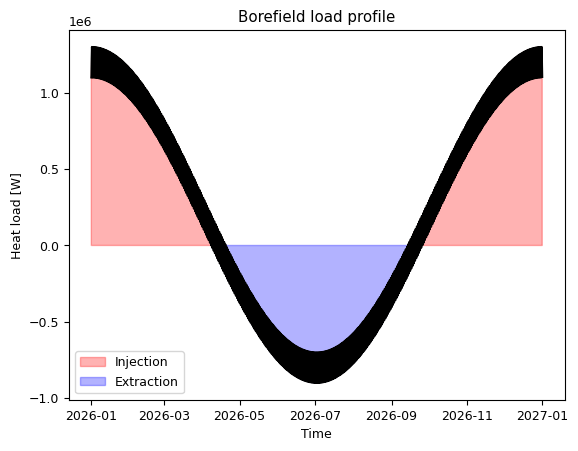

In [131]:
plt.figure()
plt.plot(load_df.index, load_df["load"], color="k")
plt.fill_between(
    load_df.index,
    0,
    load_df["load"],
    where=load_df["load"] > 0,
    color="red",
    alpha=0.3,
    label="Injection",
)
plt.fill_between(
    load_df.index,
    0,
    load_df["load"],
    where=load_df["load"] < 0,
    color="blue",
    alpha=0.3,
    label="Extraction",
)
plt.xlabel("Time")
plt.ylabel("Heat load [W]")
plt.title("Borefield load profile")
plt.legend()
plt.show()


In [132]:
def compute_fluid_temperatures(
    load_W, time_s, gfunc, k, H, T_ground, m_dot, cp
):
    Rb = 1 / (2 * np.pi * k * H)

    Tb = np.zeros_like(load_W, dtype=float)

    for i in range(1, len(load_W)):
        for j in range(i):
            Tb[i] += load_W[j] * (gfunc[i - j] - gfunc[i - j - 1])

    Tb = T_ground + Rb * Tb

    Tf_out = Tb + load_W / (m_dot * cp)
    Tf_in = Tb - load_W / (m_dot * cp)

    return Tb, Tf_in, Tf_out


Tb, Tf_in, Tf_out = compute_fluid_temperatures(
    load_df["load"].values,
    time_s,
    gfunc.gFunc,
    k,
    boreholes[0].H,
    T_ground,
    m_dot=0.25,
    cp=4180,
)

plt.figure()
plt.plot(time_s / 86400, Tf_in, label="Fluid inlet")
plt.plot(time_s / 86400, Tf_out, label="Fluid outlet")
plt.xlabel("Time [days]")
plt.ylabel("Temperature [°C]")
plt.title("Fluid temperatures")
plt.legend()
plt.show()



IndexError: index 50 is out of bounds for axis 0 with size 50

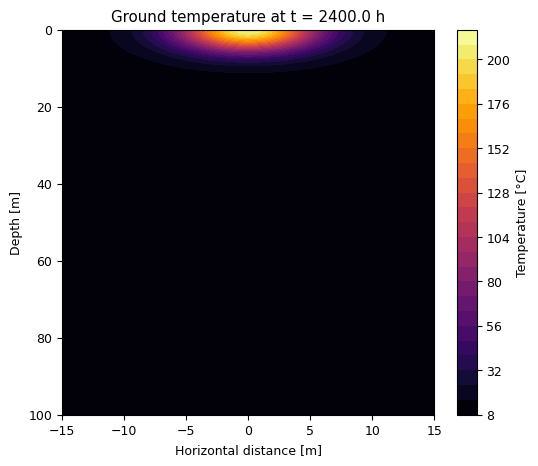

In [135]:
def plot_ground_temperature_2D(
    x, z, t, Q, k, alpha, T_ground
):
    r = np.sqrt(x**2 + z**2)
    r[r == 0] = 1e-6

    T = T_ground + (Q / (4 * np.pi * k)) * np.exp(-r**2 / (4 * alpha * t))

    plt.figure(figsize=(6, 5))
    plt.contourf(x, z, T, levels=30, cmap="inferno")
    plt.colorbar(label="Temperature [°C]")
    plt.xlabel("Horizontal distance [m]")
    plt.ylabel("Depth [m]")
    plt.title(f"Ground temperature at t = {t/3600:.1f} h")
    plt.gca().invert_yaxis()
    plt.show()

x = np.linspace(-15, 15, 120)
z = np.linspace(0, boreholes[0].H, 120)
X, Z = np.meshgrid(x, z)

plot_ground_temperature_2D(
    X, Z,
    t=100 * 24 * 3600,  # 30 days
    Q=5000,            # W
    k=k,
    alpha=alpha,
    T_ground=T_ground
)



Time vector for g-function calculation:
  50 time steps from 24 hours to 8760 hours
  Corresponds to 2026-01-01 00:00:00 to 2026-12-31 23:00:00 hours in load profile

CALCULATING G-FUNCTION
Identifying similarities ... 0.007 sec
------------------------------------------------------------
   Calculating g-function for boundary condition : 'UHTR'   
------------------------------------------------------------
Calculating segment to segment response factors ... 0.593 sec
Building and solving the system of equations ... 0.300 sec
Total time for g-function evaluation: 0.894 sec
------------------------------------------------------------

VISUALIZING RESULTS


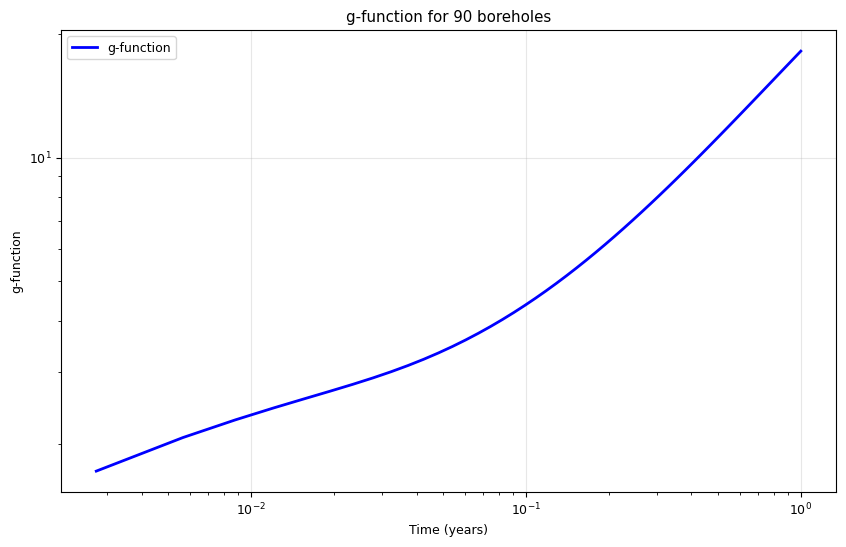

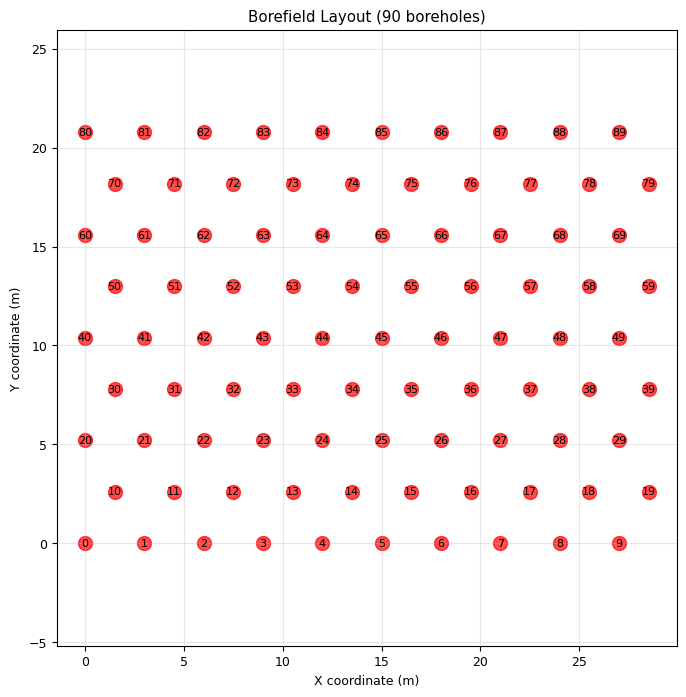

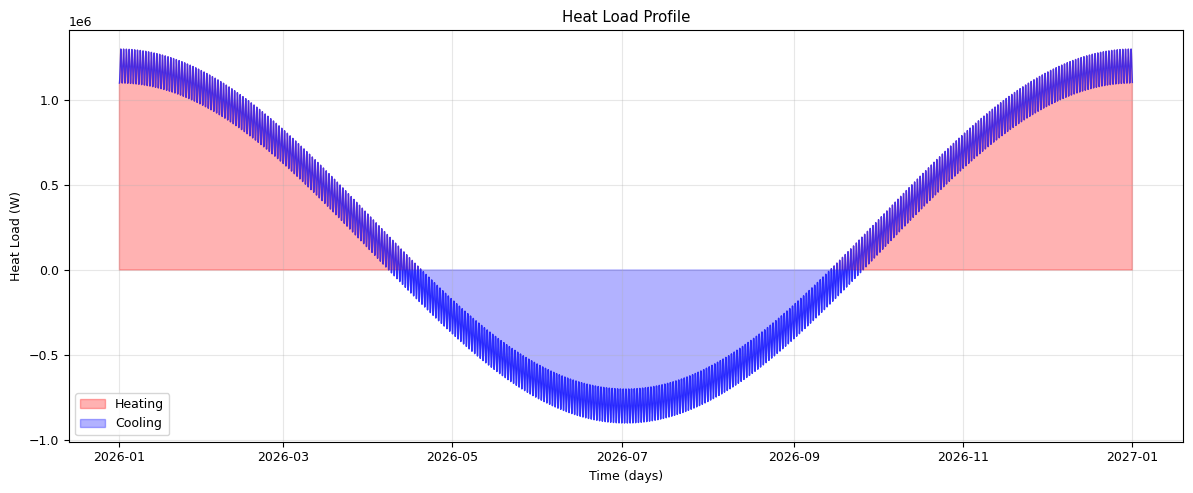


EXPORTING RESULTS
g-function saved to: g_function_results.csv
Summary saved to: simulation_summary.txt


In [124]:
def main():
    """Main function to run the simulation"""
    bore_field
    k, alpha, rhoCp, T_ground
    load_df
    
    # 6. Setup time vector for g-function calculation
    # Convert heat load hours to seconds for g-function
    max_hour = len(load_df.index)
    tmax = max_hour * 3600  # Convert hours to seconds
    
    # Create geometrically expanding time vector
    dt = 24 * 3600  # 1 day in seconds
    Nt = 50  # Number of time steps
    time = gt.utilities.time_geometric(dt, tmax, Nt)
    
    print(f"\nTime vector for g-function calculation:")
    print(f"  {Nt} time steps from {dt/3600:.0f} hours to {tmax/3600:.0f} hours")
    print(f"  Corresponds to {load_df.index.min()} to {load_df.index.max()} hours in load profile")
    
    # 7. Calculate g-function
    print("\n" + "=" * 80)
    print("CALCULATING G-FUNCTION")
    print("=" * 80)
    
    options = {
        'nSegments': 12,
        'segment_ratios': None,
        'disp': True,
        'profiles': True,
    }
    
    method = 'similarities'
    
    try:
        gfunc = gt.gfunction.gFunction(
            boreholes,
            alpha,
            time=time,
            boundary_condition='UHTR',
            options=options,
            method=method
        )
        
        # 8. Visualize results
        print("\n" + "=" * 80)
        print("VISUALIZING RESULTS")
        print("=" * 80)
        
        # Plot g-function
        fig1, ax1 = plt.subplots(1, 1, figsize=(10, 6))
        ax1.loglog(time/(365.25*24*3600), gfunc.gFunc, 'b-', linewidth=2, label='g-function')
        ax1.set_xlabel('Time (years)')
        ax1.set_ylabel('g-function')
        ax1.set_title(f'g-function for {len(boreholes)} boreholes')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot borefield layout
        fig2, ax2 = plt.subplots(1, 1, figsize=(8, 8))
        x_coords = [b.x for b in boreholes]
        y_coords = [b.y for b in boreholes]
        ax2.scatter(x_coords, y_coords, s=100, c='red', alpha=0.7)
        
        # Add borehole labels
        for i, (x, y) in enumerate(zip(x_coords, y_coords)):
            ax2.text(x, y, f'{i}', ha='center', va='center', fontsize=8)
        
        ax2.set_xlabel('X coordinate (m)')
        ax2.set_ylabel('Y coordinate (m)')
        ax2.set_title(f'Borefield Layout ({len(boreholes)} boreholes)')
        ax2.grid(True, alpha=0.3)
        ax2.axis('equal')
        
        # Plot heat load profile
        fig3, ax3 = plt.subplots(1, 1, figsize=(12, 5))
        ax3.plot(load_df.index, load_df['load'], 'b-', linewidth=1, alpha=0.7)
        ax3.fill_between(load_df.index, 0, load_df['load'], 
                         where=load_df['load']>0, color='red', alpha=0.3, label='Heating')
        ax3.fill_between(load_df.index, 0, load_df['load'], 
                         where=load_df['load']<0, color='blue', alpha=0.3, label='Cooling')
        ax3.set_xlabel('Time (days)')
        ax3.set_ylabel('Heat Load (W)')
        ax3.set_title('Heat Load Profile')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        
        plt.tight_layout()
        plt.show()
        
        # 9. Export results
        print("\n" + "=" * 80)
        print("EXPORTING RESULTS")
        print("=" * 80)
        
        # Save g-function to CSV
        results_df = pd.DataFrame({
            'time_hours': time/3600,
            'time_years': time/(365.25*24*3600),
            'g_function': gfunc.gFunc
        })
        results_df.to_csv('g_function_results.csv', index=False)
        print(f"g-function saved to: g_function_results.csv")
        
        # Save summary
        with open('simulation_summary.txt', 'w') as f:
            f.write("SIMULATION SUMMARY\n")
            f.write("=" * 60 + "\n")
            f.write(f"Number of boreholes: {len(boreholes)}\n")
            # f.write(f"Borehole length range: {min(borehole_depths):.1f} - {max(borehole_depths):.1f} m\n")
            f.write(f"Effective thermal conductivity: {k:.3f} W/m.K\n")
            f.write(f"Effective thermal diffusivity: {alpha:.2e} m2/s\n")
            f.write(f"Total simulation time: {tmax/3600:.0f} hours ({tmax/(8760*3600):.1f} years)\n")
            f.write(f"Peak heat load: {load_df['load'].max():.0f} W (heating)\n")
            f.write(f"Peak cooling load: {abs(load_df['load'].min()):.0f} W (cooling)\n")
        
        print(f"Summary saved to: simulation_summary.txt")
        
    except Exception as e:
        print(f"\nError during g-function calculation: {e}")
        print("Check your input parameters and try again.")

if __name__ == '__main__':
    main()

Identifying equivalent boreholes ... 0.004 sec
Calculations will be done using 3 equivalent boreholes
------------------------------------------------------------
   Calculating g-function for boundary condition : 'MIFT'   
------------------------------------------------------------
Calculating segment to segment response factors ... 0.157 sec
Building and solving the system of equations ... 0.017 sec
Total time for g-function evaluation: 0.175 sec
------------------------------------------------------------


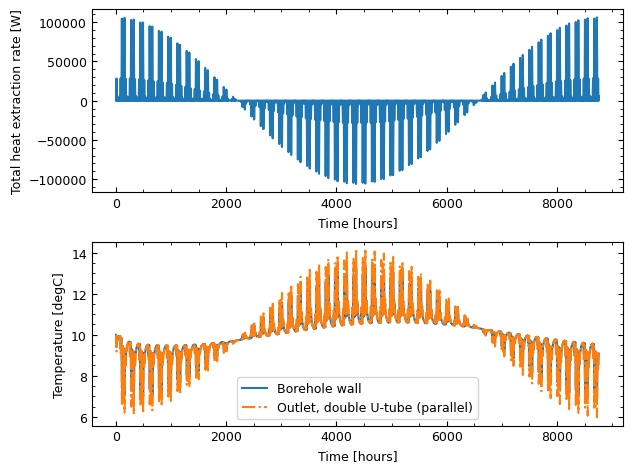

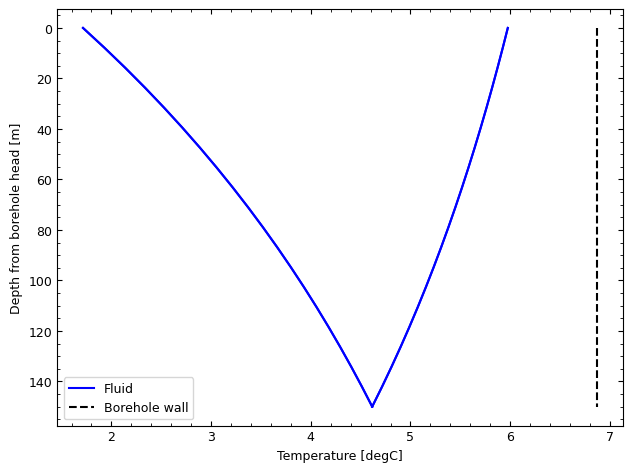

In [136]:
# -*- coding: utf-8 -*-
""" Example of simulation of a geothermal system with multiple boreholes.

    The g-function of a bore field is calculated for boundary condition of
    mixed inlet fluid temperature into the boreholes. Then, the borehole
    wall temperature variations resulting from a time-varying load profile
    are simulated using the aggregation method of Claesson and Javed (2012).
    Predicted outlet fluid temperatures of double U-tube borehole are
    evaluated.

"""
import matplotlib.pyplot as plt
import numpy as np

import pygfunction as gt


def main():
    # -------------------------------------------------------------------------
    # Simulation parameters
    # -------------------------------------------------------------------------

    # Borehole dimensions
    D = 4.0             # Borehole buried depth (m)
    H = 150.0           # Borehole length (m)
    r_b = 0.075         # Borehole radius (m)

    # Bore field geometry (rectangular array)
    N_1 = 6             # Number of boreholes in the x-direction (columns)
    N_2 = 4             # Number of boreholes in the y-direction (rows)
    B = 7.5             # Borehole spacing, in both directions (m)

    # Pipe dimensions
    r_out = 0.0211      # Pipe outer radius (m)
    r_in = 0.0147       # Pipe inner radius (m)
    D_s = 0.052         # Shank spacing (m)
    epsilon = 1.0e-6    # Pipe roughness (m)

    # Pipe positions
    # Double U-tube [(x_in1, y_in1), (x_in2, y_in2),
    #                (x_out1, y_out1), (x_out2, y_out2)]
    pos = [(-D_s, 0.), (0., -D_s), (D_s, 0.), (0., D_s)]

    # Ground properties
    alpha = 1.0e-6      # Ground thermal diffusivity (m2/s)
    k_s = 2.0           # Ground thermal conductivity (W/m.K)
    T_g = 10.0          # Undisturbed ground temperature (degC)

    # Grout properties
    k_g = 1.0           # Grout thermal conductivity (W/m.K)

    # Pipe properties
    k_p = 0.4           # Pipe thermal conductivity (W/m.K)

    # Fluid properties
    m_flow_borehole = 0.25      # Total fluid mass flow rate per borehole (kg/s)
    # Total fluid mass flow rate (kg/s)
    m_flow_network = m_flow_borehole * N_1 * N_2
    # The fluid is propylene-glycol (20 %) at 20 degC
    fluid = gt.media.Fluid('MPG', 20.)
    cp_f = fluid.cp     # Fluid specific isobaric heat capacity (J/kg.K)
    rho_f = fluid.rho   # Fluid density (kg/m3)
    mu_f = fluid.mu     # Fluid dynamic viscosity (kg/m.s)
    k_f = fluid.k       # Fluid thermal conductivity (W/m.K)

    # g-Function calculation options
    options = {'nSegments': 8,
               'disp': True}

    # Simulation parameters
    dt = 3600.                  # Time step (s)
    tmax = 1.*8760. * 3600.     # Maximum time (s)
    Nt = int(np.ceil(tmax/dt))  # Number of time steps
    time = dt * np.arange(1, Nt+1)

    # Load aggregation scheme
    LoadAgg = gt.load_aggregation.ClaessonJaved(dt, tmax)

    # -------------------------------------------------------------------------
    # Initialize bore field and pipe models
    # -------------------------------------------------------------------------

    # The field is a retangular array
    borefield = gt.borefield.Borefield.rectangle_field(
        N_1, N_2, B, B, H, D, r_b)
    nBoreholes = len(borefield)

    # Pipe thermal resistance
    R_p = gt.pipes.conduction_thermal_resistance_circular_pipe(
            r_in, r_out, k_p)

    # Fluid to inner pipe wall thermal resistance (Double U-tube in parallel)
    m_flow_pipe = m_flow_borehole/2
    h_f = gt.pipes.convective_heat_transfer_coefficient_circular_pipe(
            m_flow_pipe, r_in, mu_f, rho_f, k_f, cp_f, epsilon)
    R_f = 1.0 / (h_f * 2 * np.pi * r_in)

    # Double U-tube (parallel), same for all boreholes in the bore field
    UTubes = []
    for borehole in borefield:
        UTube = gt.pipes.MultipleUTube(
            pos, r_in, r_out, borehole, k_s, k_g, R_f + R_p,
            nPipes=2, config='parallel')
        UTubes.append(UTube)
    # Build a network object from the list of UTubes
    network = gt.networks.Network(borefield, UTubes)

    # -------------------------------------------------------------------------
    # Calculate g-function
    # -------------------------------------------------------------------------

    # Get time values needed for g-function evaluation
    time_req = LoadAgg.get_times_for_simulation()
    # Calculate g-function
    gFunc = gt.gfunction.gFunction(
        network, alpha, time=time_req, m_flow_network=m_flow_network,
        cp_f=cp_f, boundary_condition='MIFT', options=options)
    # Initialize load aggregation scheme
    LoadAgg.initialize(gFunc.gFunc / (2 * np.pi * k_s))

    # -------------------------------------------------------------------------
    # Simulation
    # -------------------------------------------------------------------------

    # Evaluate heat extraction rate
    Q_tot = nBoreholes*synthetic_load(time / 3600.)

    T_b = np.zeros(Nt)
    T_f_in = np.zeros(Nt)
    T_f_out = np.zeros(Nt)
    for i, (t, Q_i) in enumerate(zip(time, Q_tot)):
        # Increment time step by (1)
        LoadAgg.next_time_step(t)

        # Apply current load (in watts per meter of borehole)
        Q_b = Q_i/nBoreholes
        LoadAgg.set_current_load(Q_b/H)

        # Evaluate borehole wall temperature
        deltaT_b = LoadAgg.temporal_superposition()
        T_b[i] = T_g - deltaT_b

        # Evaluate inlet fluid temperature (all boreholes are the same)
        T_f_in[i] = network.get_network_inlet_temperature(
                Q_tot[i], T_b[i], m_flow_network, cp_f, nSegments=1)

        # Evaluate outlet fluid temperature
        T_f_out[i] = network.get_network_outlet_temperature(
                T_f_in[i],  T_b[i], m_flow_network, cp_f, nSegments=1)

    # -------------------------------------------------------------------------
    # Plot hourly heat extraction rates and temperatures
    # -------------------------------------------------------------------------

    # Configure figure and axes
    fig = gt.utilities._initialize_figure()

    ax1 = fig.add_subplot(211)
    # Axis labels
    ax1.set_xlabel(r'Time [hours]')
    ax1.set_ylabel(r'Total heat extraction rate [W]')
    gt.utilities._format_axes(ax1)

    # Plot heat extraction rates
    hours = np.arange(1, Nt+1) * dt / 3600.
    ax1.plot(hours, Q_tot)

    ax2 = fig.add_subplot(212)
    # Axis labels
    ax2.set_xlabel(r'Time [hours]')
    ax2.set_ylabel(r'Temperature [degC]')
    gt.utilities._format_axes(ax2)

    # Plot temperatures
    ax2.plot(hours, T_b, label='Borehole wall')
    ax2.plot(hours, T_f_out, '-.',
             label='Outlet, double U-tube (parallel)')
    ax2.legend()

    # Adjust to plot window
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # Plot fluid temperature profiles
    # -------------------------------------------------------------------------

    # Evaluate temperatures at nz evenly spaced depths along the borehole
    # at the (it+1)-th time step
    nz = 20
    it = 8724
    z = np.linspace(0., H, num=nz)
    T_f = UTubes[0].get_temperature(
        z, T_f_in[it], T_b[it], m_flow_borehole, cp_f)

    # Configure figure and axes
    fig = gt.utilities._initialize_figure()

    ax3 = fig.add_subplot(111)
    # Axis labels
    ax3.set_xlabel(r'Temperature [degC]')
    ax3.set_ylabel(r'Depth from borehole head [m]')
    gt.utilities._format_axes(ax3)

    # Plot temperatures
    pltFlu = ax3.plot(T_f, z, 'b-', label='Fluid')
    pltWal = ax3.plot(np.array([T_b[it], T_b[it]]), np.array([0., H]),
                      'k--', label='Borehole wall')
    ax3.legend(handles=[pltFlu[0]]+pltWal)

    # Reverse y-axes
    ax3.set_ylim(ax3.get_ylim()[::-1])
    # Adjust to plot window
    plt.tight_layout()

    return


def synthetic_load(x):
    """
    Synthetic load profile of Bernier et al. (2004).

    Returns load y (in watts) at time x (in hours).
    """
    A = 2000.0
    B = 2190.0
    C = 80.0
    D = 2.0
    E = 0.01
    F = 0.0
    G = 0.95

    func = (168.0-C)/168.0
    for i in [1, 2, 3]:
        func += 1.0/(i*np.pi)*(np.cos(C*np.pi*i/84.0)-1.0) \
                          *(np.sin(np.pi*i/84.0*(x-B)))
    func = func*A*np.sin(np.pi/12.0*(x-B)) \
           *np.sin(np.pi/4380.0*(x-B))

    y = func + (-1.0)**np.floor(D/8760.0*(x-B))*abs(func) \
      + E*(-1.0)**np.floor(D/8760.0*(x-B))/np.sign(np.cos(D*np.pi/4380.0*(x-F))+G)
    return -y


# Main function
if __name__ == '__main__':
    main()